write 2d version of totalseg
	- for each case
		- for each label 
			- get center and bbox of each label, save to dict
			- save img, mask for each axis at case_nb/label/img_ax_i.npz, label_ax_i.npz
	- for each img, compute dinov3 features

In [1]:
%load_ext autoreload
%autoreload 2

from src.config import load_config
config = load_config()
from pathlib import Path
import nibabel as nib


totalseg_dir = Path(config["paths"]["DATA_DIR"]) / "TotalSeg" 
totalseg_2d_dir = Path(config["paths"]["DATA_DIR"]) / "TotalSeg2D"

In [11]:

totalseg_stats = {} # case_id -> {label_id -> (bbox, volume, center)}

label_ids = []
case_dirs = list(totalseg_dir.iterdir())[:5]
for case_dir in case_dirs:
    if case_dir.is_dir():
        # load image
        img_nii = nib.load(str(case_dir / "ct.nii.gz"))
        labels_dir = case_dir / "segmentations"
        for label_file in labels_dir.glob("*.nii.gz"):
            label_id = label_file.name.split(".")[0]
            label_nii = nib.load(str(label_file))
            label_data = label_nii.get_fdata()
            coords = label_data.nonzero()
            if len(coords[0]) == 0:
                continue
            zmin, zmax = coords[0].min(), coords[0].max()
            ymin, ymax = coords[1].min(), coords[1].max()
            xmin, xmax = coords[2].min(), coords[2].max()
            volume = len(coords[0])  # number of voxels
            center = ( (zmin+zmax)//2, (ymin+ymax)//2, (xmin+xmax)//2 )
            totalseg_stats.setdefault(case_dir.name, {})[label_id] = {
                "bbox": ( (zmin, zmax), (ymin, ymax), (xmin, xmax) ),
                "volume": volume,
                "center": center
            }
            if label_id not in label_ids:
                label_ids.append(label_id)


In [ ]:
# PARALLEL VERSION: compute totalseg_stats
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

def compute_label_stats(args):
    """Compute stats for a single label file."""
    import nibabel as nib
    
    case_name, label_file_str = args
    label_file = Path(label_file_str)
    label_id = label_file.name.split(".")[0]
    
    try:
        label_nii = nib.load(str(label_file))
        label_data = label_nii.get_fdata()
        coords = label_data.nonzero()
        
        if len(coords[0]) == 0:
            return case_name, label_id, None  # Empty label
        
        zmin, zmax = coords[0].min(), coords[0].max()
        ymin, ymax = coords[1].min(), coords[1].max()
        xmin, xmax = coords[2].min(), coords[2].max()
        volume = len(coords[0])
        center = ((zmin+zmax)//2, (ymin+ymax)//2, (xmin+xmax)//2)
        
        stats = {
            "bbox": ((zmin, zmax), (ymin, ymax), (xmin, xmax)),
            "volume": volume,
            "center": center
        }
        return case_name, label_id, stats
    except Exception as e:
        return case_name, label_id, None

# Build list of all tasks
case_dirs = list(totalseg_dir.iterdir())  # Remove [:5] limit for full dataset
tasks = []
for case_dir in case_dirs:
    if case_dir.is_dir():
        labels_dir = case_dir / "segmentations"
        for label_file in labels_dir.glob("*.nii.gz"):
            tasks.append((case_dir.name, str(label_file)))

print(f"Total label files to process: {len(tasks)}")

# Process in parallel
n_workers = min(mp.cpu_count(), 8)
print(f"Using {n_workers} workers...")

totalseg_stats = {}
label_ids = []
completed = 0

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    futures = {executor.submit(compute_label_stats, task): task for task in tasks}
    
    for future in as_completed(futures):
        case_name, label_id, stats = future.result()
        completed += 1
        
        if stats is not None:
            totalseg_stats.setdefault(case_name, {})[label_id] = stats
            if label_id not in label_ids:
                label_ids.append(label_id)
        
        if completed % 100 == 0:
            print(f"Progress: {completed}/{len(tasks)} ({100*completed/len(tasks):.1f}%)")

print(f"\nCompleted: {completed}/{len(tasks)}")
print(f"Cases with stats: {len(totalseg_stats)}")
print(f"Unique labels: {len(label_ids)}")

Total label files to process: 143676
Using 8 workers...
Progress: 100/143676 (0.1%)
Progress: 200/143676 (0.1%)
Progress: 300/143676 (0.2%)
Progress: 400/143676 (0.3%)
Progress: 500/143676 (0.3%)
Progress: 600/143676 (0.4%)
Progress: 700/143676 (0.5%)
Progress: 800/143676 (0.6%)
Progress: 900/143676 (0.6%)
Progress: 1000/143676 (0.7%)
Progress: 1100/143676 (0.8%)
Progress: 1200/143676 (0.8%)
Progress: 1300/143676 (0.9%)
Progress: 1400/143676 (1.0%)
Progress: 1500/143676 (1.0%)
Progress: 1600/143676 (1.1%)
Progress: 1700/143676 (1.2%)
Progress: 1800/143676 (1.3%)
Progress: 1900/143676 (1.3%)
Progress: 2000/143676 (1.4%)
Progress: 2100/143676 (1.5%)
Progress: 2200/143676 (1.5%)
Progress: 2300/143676 (1.6%)
Progress: 2400/143676 (1.7%)
Progress: 2500/143676 (1.7%)
Progress: 2600/143676 (1.8%)
Progress: 2700/143676 (1.9%)
Progress: 2800/143676 (1.9%)
Progress: 2900/143676 (2.0%)
Progress: 3000/143676 (2.1%)
Progress: 3100/143676 (2.2%)
Progress: 3200/143676 (2.2%)
Progress: 3300/143676 (2.

KeyboardInterrupt: 

In [5]:
# save stats
import pickle
with open(totalseg_dir / "totalseg_stats.pkl", "wb") as f:
    pickle.dump(totalseg_stats, f)

In [21]:
# for each case, each label, extract 2D slices containing the label and save to totalseg_2d_dir

for case_dir in case_dirs:
    if case_dir.is_dir():
        print(f"Processing case {case_dir.name}...")
        labels_dir = case_dir / "segmentations"
        for label_file in labels_dir.glob("*.nii.gz"):
            label_id = label_file.name.split(".")[0]
            # Skip if label was empty (not in totalseg_stats)
            if label_id not in totalseg_stats.get(case_dir.name, {}):
                continue
            print(f"  Processing label {label_file.name}...")
            label_nii = nib.load(str(label_file))
            label_data = label_nii.get_fdata()
            # z, y, x slices at label center
            center = totalseg_stats[case_dir.name][label_id]["center"]
            zc, yc, xc = center
            slices = {"z": label_data[zc, :, :],
                      "y": label_data[:, yc, :],
                      "x": label_data[:, :, xc]}
            img_nii = nib.load(str(case_dir / "ct.nii.gz"))
            img_data = img_nii.get_fdata()
            img_slices = {"z": img_data[zc, :, :],
                          "y": img_data[:, yc, :],
                          "x": img_data[:, :, xc]}

            for axis, slice_data in slices.items():
                save_dir = totalseg_2d_dir / case_dir.name / label_id
                save_dir.mkdir(parents=True, exist_ok=True)
                slice_nii = nib.Nifti1Image(slice_data.astype(label_data.dtype), affine=label_nii.affine)
                nib.save(slice_nii, str(save_dir / f"{axis}_slice.nii.gz"))
                # save original image slice as well
                img_slice_nii = nib.Nifti1Image(img_slices[axis].astype(img_data.dtype), affine=img_nii.affine)
                nib.save(img_slice_nii, str(save_dir / f"{axis}_slice_img.nii.gz"))

Processing case s1298...
  Processing label common_carotid_artery_left.nii.gz...
  Processing label clavicula_right.nii.gz...
  Processing label brachiocephalic_vein_left.nii.gz...
  Processing label heart.nii.gz...
  Processing label trachea.nii.gz...
  Processing label vertebrae_T2.nii.gz...
  Processing label rib_right_9.nii.gz...
  Processing label rib_right_4.nii.gz...
  Processing label vertebrae_L2.nii.gz...
  Processing label thyroid_gland.nii.gz...
  Processing label vertebrae_C7.nii.gz...
  Processing label humerus_left.nii.gz...
  Processing label pulmonary_vein.nii.gz...
  Processing label costal_cartilages.nii.gz...
  Processing label spinal_cord.nii.gz...
  Processing label vertebrae_T11.nii.gz...
  Processing label scapula_right.nii.gz...
  Processing label inferior_vena_cava.nii.gz...
  Processing label rib_left_2.nii.gz...
  Processing label rib_right_6.nii.gz...
  Processing label autochthon_right.nii.gz...
  Processing label lung_lower_lobe_right.nii.gz...
  Processi

In [ ]:
# PARALLEL VERSION: for each case, each label, extract 2D slices and save to totalseg_2d_dir
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

def process_label(args):
    """Process a single label: extract 2D slices and save them."""
    import nibabel as nib
    from pathlib import Path
    
    case_name, label_id, case_path_str, stats, output_dir_str = args
    case_path = Path(case_path_str)
    output_dir = Path(output_dir_str)
    
    try:
        label_file = case_path / "segmentations" / f"{label_id}.nii.gz"
        label_nii = nib.load(str(label_file))
        label_data = label_nii.get_fdata()
        
        # z, y, x slices at label center
        center = stats["center"]
        zc, yc, xc = center
        slices = {"z": label_data[zc, :, :],
                  "y": label_data[:, yc, :],
                  "x": label_data[:, :, xc]}
        
        img_nii = nib.load(str(case_path / "ct.nii.gz"))
        img_data = img_nii.get_fdata()
        img_slices = {"z": img_data[zc, :, :],
                      "y": img_data[:, yc, :],
                      "x": img_data[:, :, xc]}

        for axis, slice_data in slices.items():
            save_dir = output_dir / case_name / label_id
            save_dir.mkdir(parents=True, exist_ok=True)
            slice_nii = nib.Nifti1Image(slice_data.astype(label_data.dtype), affine=label_nii.affine)
            nib.save(slice_nii, str(save_dir / f"{axis}_slice.nii.gz"))
            # save original image slice as well
            img_slice_nii = nib.Nifti1Image(img_slices[axis].astype(img_data.dtype), affine=img_nii.affine)
            nib.save(img_slice_nii, str(save_dir / f"{axis}_slice_img.nii.gz"))
        
        return f"{case_name}/{label_id}", True, None
    except Exception as e:
        return f"{case_name}/{label_id}", False, str(e)

# Build list of all tasks (use strings for paths to allow pickling)
tasks = []
for case_dir in case_dirs:
    if case_dir.is_dir():
        case_stats = totalseg_stats.get(case_dir.name, {})
        for label_id, stats in case_stats.items():
            tasks.append((case_dir.name, label_id, str(case_dir), stats, str(totalseg_2d_dir)))

print(f"Total tasks: {len(tasks)}")

# Process in parallel
n_workers = min(mp.cpu_count(), 8)  # Cap at 8 workers to avoid memory issues
print(f"Using {n_workers} workers...")

completed = 0
errors = []

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    futures = {executor.submit(process_label, task): task for task in tasks}
    
    for future in as_completed(futures):
        name, success, error = future.result()
        completed += 1
        if not success:
            errors.append((name, error))
        if completed % 50 == 0:
            print(f"Progress: {completed}/{len(tasks)} ({100*completed/len(tasks):.1f}%)")

print(f"\nCompleted: {completed}/{len(tasks)}")
if errors:
    print(f"Errors ({len(errors)}):")
    for name, err in errors[:10]:  # Show first 10 errors
        print(f"  {name}: {err}")

In [2]:
# OPTIMIZED PARALLEL VERSION: compute stats AND extract slices in one pass
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

def process_label_full(args):
    """Compute stats and extract 2D slices in a single pass."""
    import nibabel as nib
    from pathlib import Path
    
    case_name, label_file_str, case_path_str, output_dir_str = args
    label_file = Path(label_file_str)
    case_path = Path(case_path_str)
    output_dir = Path(output_dir_str)
    label_id = label_file.name.split(".")[0]
    
    try:
        # Load label data
        label_nii = nib.load(str(label_file))
        label_data = label_nii.get_fdata()
        
        # Compute stats
        coords = label_data.nonzero()
        if len(coords[0]) == 0:
            return case_name, label_id, None, True, None  # Empty label, skip
        
        zmin, zmax = int(coords[0].min()), int(coords[0].max())
        ymin, ymax = int(coords[1].min()), int(coords[1].max())
        xmin, xmax = int(coords[2].min()), int(coords[2].max())
        volume = len(coords[0])
        center = ((zmin+zmax)//2, (ymin+ymax)//2, (xmin+xmax)//2)
        
        stats = {
            "bbox": ((zmin, zmax), (ymin, ymax), (xmin, xmax)),
            "volume": volume,
            "center": center
        }
        
        # Extract slices at label center
        zc, yc, xc = center
        slices = {"z": label_data[zc, :, :],
                  "y": label_data[:, yc, :],
                  "x": label_data[:, :, xc]}
        
        # Load image data (only once per label)
        img_nii = nib.load(str(case_path / "ct.nii.gz"))
        img_data = img_nii.get_fdata()
        img_slices = {"z": img_data[zc, :, :],
                      "y": img_data[:, yc, :],
                      "x": img_data[:, :, xc]}
        
        # Save slices
        for axis, slice_data in slices.items():
            save_dir = output_dir / case_name / label_id
            save_dir.mkdir(parents=True, exist_ok=True)
            slice_nii = nib.Nifti1Image(slice_data.astype(label_data.dtype), affine=label_nii.affine)
            nib.save(slice_nii, str(save_dir / f"{axis}_slice.nii.gz"))
            img_slice_nii = nib.Nifti1Image(img_slices[axis].astype(img_data.dtype), affine=img_nii.affine)
            nib.save(img_slice_nii, str(save_dir / f"{axis}_slice_img.nii.gz"))
        
        return case_name, label_id, stats, True, None
    except Exception as e:
        return case_name, label_id, None, False, str(e)

# Build list of all tasks
case_dirs = list(totalseg_dir.iterdir())  # Full dataset
tasks = []
for case_dir in case_dirs:
    if case_dir.is_dir():
        labels_dir = case_dir / "segmentations"
        for label_file in labels_dir.glob("*.nii.gz"):
            tasks.append((case_dir.name, str(label_file), str(case_dir), str(totalseg_2d_dir)))

print(f"Total label files to process: {len(tasks)}")

# Process in parallel
n_workers = min(mp.cpu_count(), 8)
print(f"Using {n_workers} workers...")

totalseg_stats = {}
label_ids = []
completed = 0
errors = []

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    futures = {executor.submit(process_label_full, task): task for task in tasks}
    
    for future in as_completed(futures):
        case_name, label_id, stats, success, error = future.result()
        completed += 1
        
        if stats is not None:
            totalseg_stats.setdefault(case_name, {})[label_id] = stats
            if label_id not in label_ids:
                label_ids.append(label_id)
        
        if not success and error is not None:
            errors.append((f"{case_name}/{label_id}", error))
        
        if completed % 100 == 0:
            print(f"Progress: {completed}/{len(tasks)} ({100*completed/len(tasks):.1f}%)")

print(f"\nCompleted: {completed}/{len(tasks)}")
print(f"Cases with stats: {len(totalseg_stats)}")
print(f"Unique labels: {len(label_ids)}")
if errors:
    print(f"Errors ({len(errors)}):")
    for name, err in errors[:10]:
        print(f"  {name}: {err}")

Total label files to process: 143676
Using 8 workers...
Progress: 100/143676 (0.1%)
Progress: 200/143676 (0.1%)
Progress: 300/143676 (0.2%)
Progress: 400/143676 (0.3%)
Progress: 500/143676 (0.3%)
Progress: 600/143676 (0.4%)
Progress: 700/143676 (0.5%)
Progress: 800/143676 (0.6%)
Progress: 900/143676 (0.6%)
Progress: 1000/143676 (0.7%)
Progress: 1100/143676 (0.8%)
Progress: 1200/143676 (0.8%)
Progress: 1300/143676 (0.9%)
Progress: 1400/143676 (1.0%)
Progress: 1500/143676 (1.0%)
Progress: 1600/143676 (1.1%)
Progress: 1700/143676 (1.2%)
Progress: 1800/143676 (1.3%)
Progress: 1900/143676 (1.3%)
Progress: 2000/143676 (1.4%)
Progress: 2100/143676 (1.5%)
Progress: 2200/143676 (1.5%)
Progress: 2300/143676 (1.6%)
Progress: 2400/143676 (1.7%)
Progress: 2500/143676 (1.7%)
Progress: 2600/143676 (1.8%)
Progress: 2700/143676 (1.9%)
Progress: 2800/143676 (1.9%)
Progress: 2900/143676 (2.0%)
Progress: 3000/143676 (2.1%)
Progress: 3100/143676 (2.2%)
Progress: 3200/143676 (2.2%)
Progress: 3300/143676 (2.

Loaded stats for 5 cases
Built mapping for 4 labels
Created 60 samples
Dataset size: 60
Target case: s1298
Label: kidney_left, Axis: z
Context cases: ['s0844', 's1201', 's1395']
Target shape: torch.Size([1, 256, 256])
Context shape: torch.Size([3, 1, 256, 256])


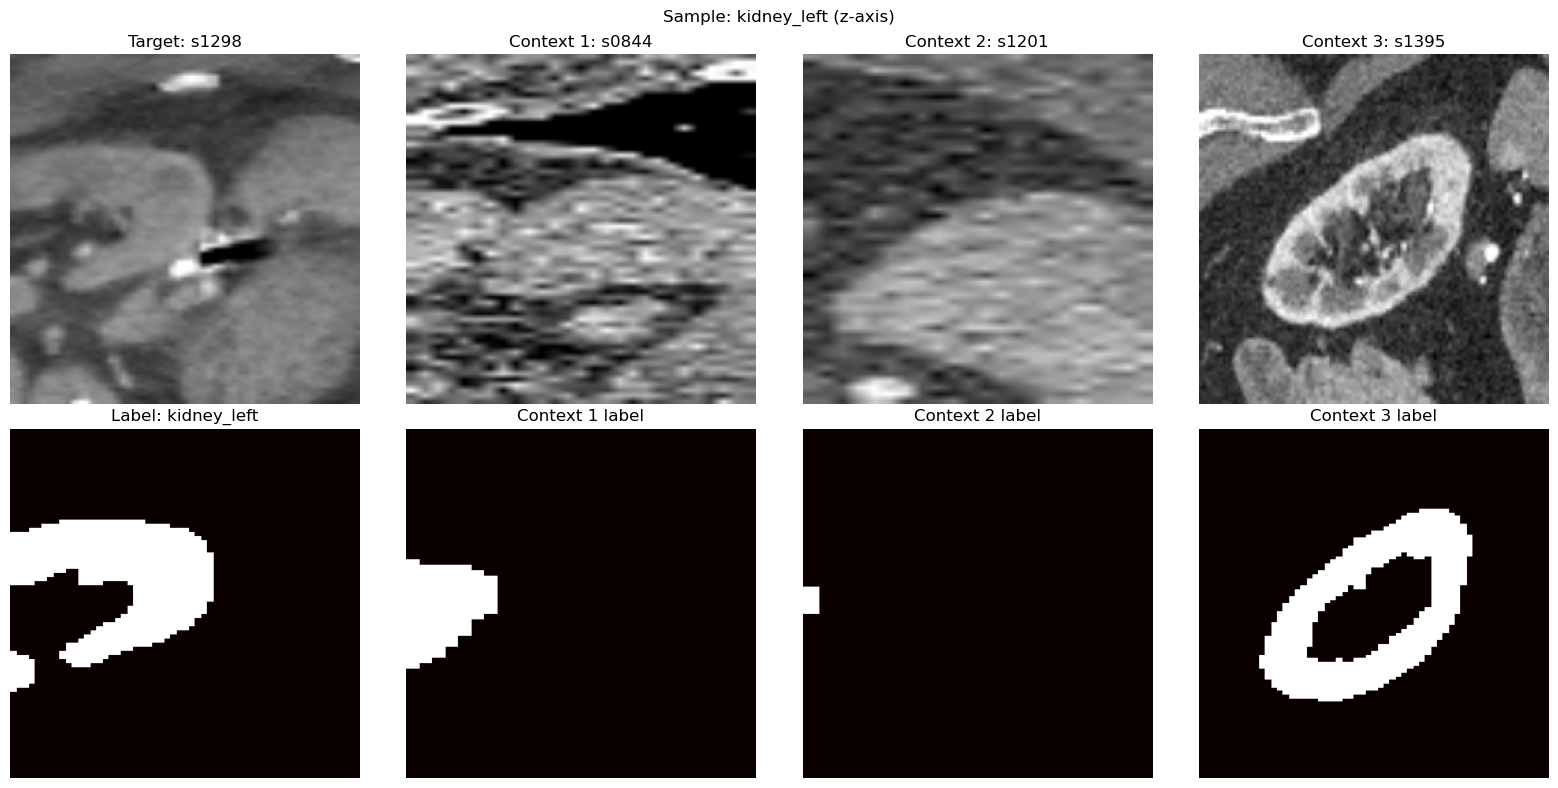

In [3]:
# Load dataset and plot first element
import matplotlib.pyplot as plt
from src.dataloaders.totalseg2d_dataloader import TotalSeg2DDataset

# Create dataset
dataset = TotalSeg2DDataset(
    root_dir=str(totalseg_2d_dir),
    stats_path=str(totalseg_dir / "totalseg_stats.pkl"),
    label_id_list=["liver", "spleen", "kidney_left", "kidney_right"],
    context_size=3,
    image_size=(256, 256),
    crop_to_bbox=True,
    bbox_padding=20,
)

print(f"Dataset size: {len(dataset)}")

# Get first sample
sample = dataset[0]
print(f"Target case: {sample['target_case_id']}")
print(f"Label: {sample['label_id']}, Axis: {sample['axis']}")
print(f"Context cases: {sample['context_case_ids']}")
print(f"Target shape: {sample['target_in'].shape}")
print(f"Context shape: {sample['context_in'].shape}")

# Plot target and contexts
k = sample['context_in'].shape[0]
fig, axes = plt.subplots(2, k + 1, figsize=(4 * (k + 1), 8))

# Target
axes[0, 0].imshow(sample['target_in'][0], cmap='gray')
axes[0, 0].set_title(f"Target: {sample['target_case_id']}")
axes[0, 0].axis('off')

axes[1, 0].imshow(sample['target_out'][0], cmap='hot')
axes[1, 0].set_title(f"Label: {sample['label_id']}")
axes[1, 0].axis('off')

# Contexts
for i in range(k):
    axes[0, i + 1].imshow(sample['context_in'][i, 0], cmap='gray')
    axes[0, i + 1].set_title(f"Context {i+1}: {sample['context_case_ids'][i]}")
    axes[0, i + 1].axis('off')
    
    axes[1, i + 1].imshow(sample['context_out'][i, 0], cmap='hot')
    axes[1, i + 1].set_title(f"Context {i+1} label")
    axes[1, i + 1].axis('off')

plt.suptitle(f"Sample: {sample['label_id']} ({sample['axis']}-axis)")
plt.tight_layout()
plt.show()

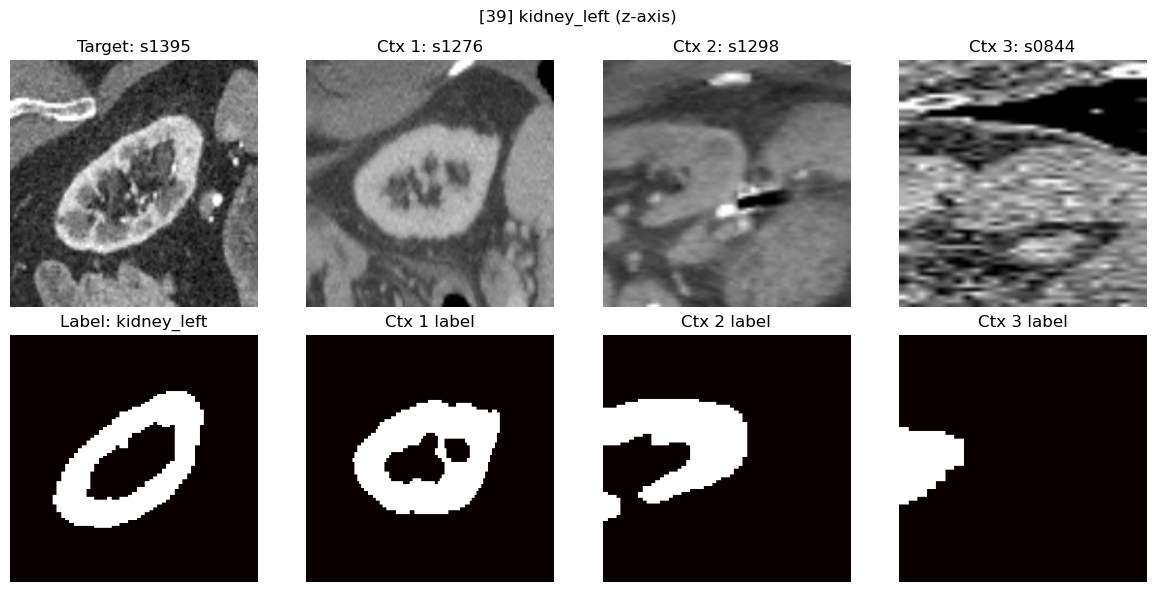

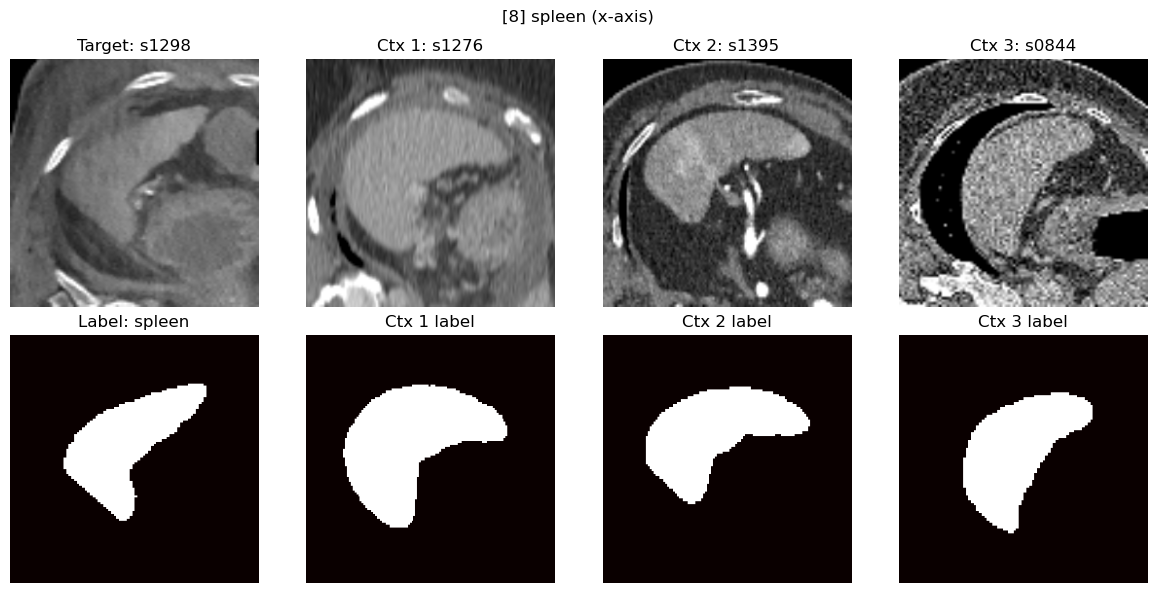

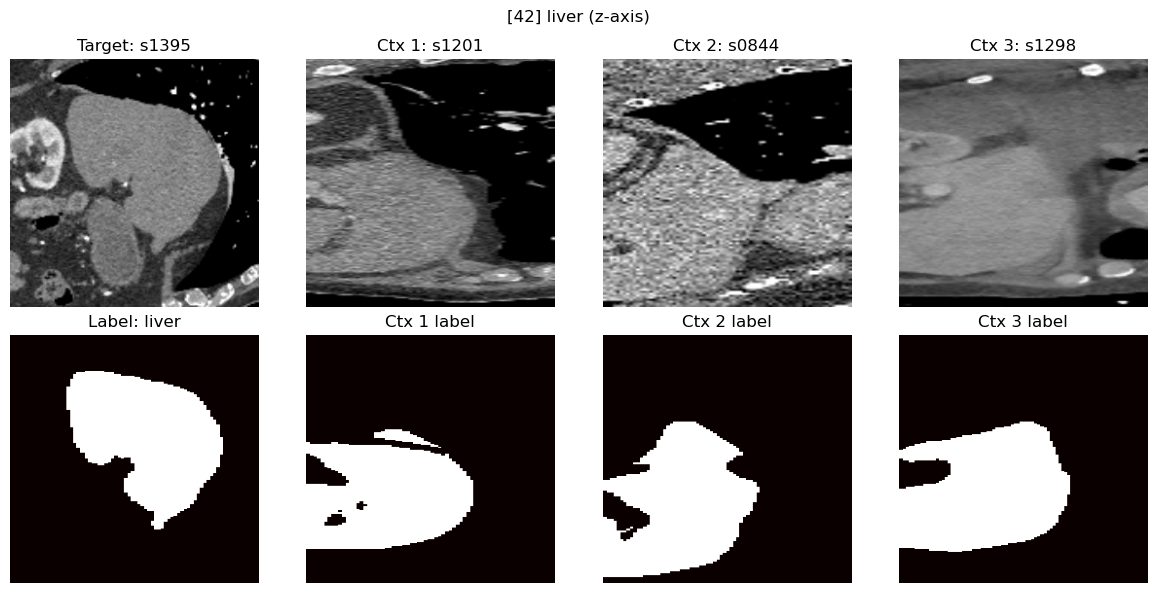

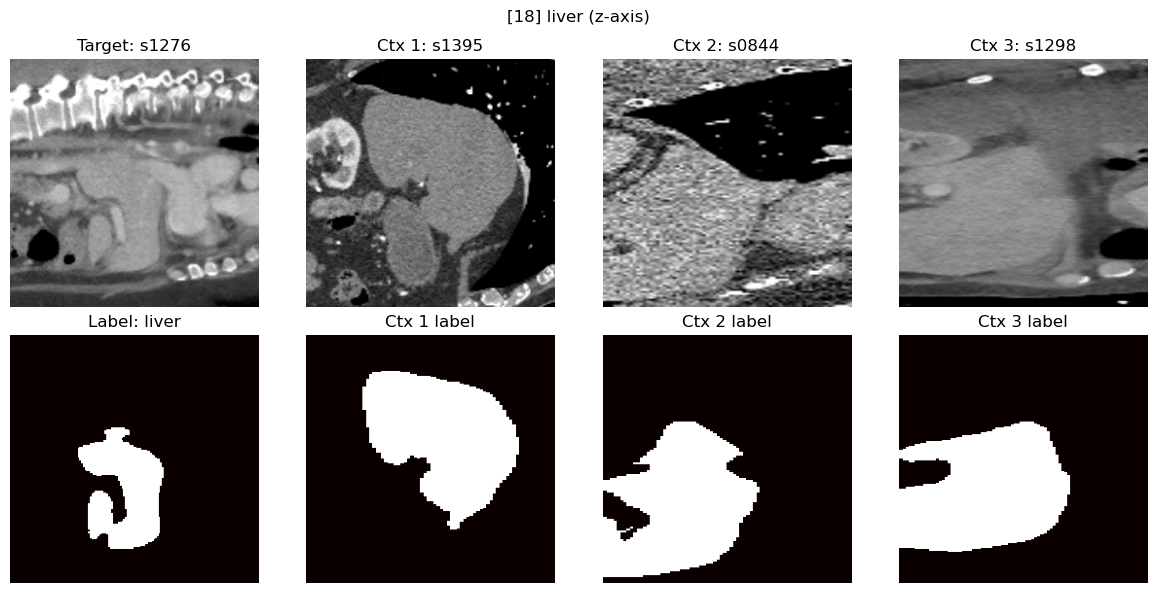

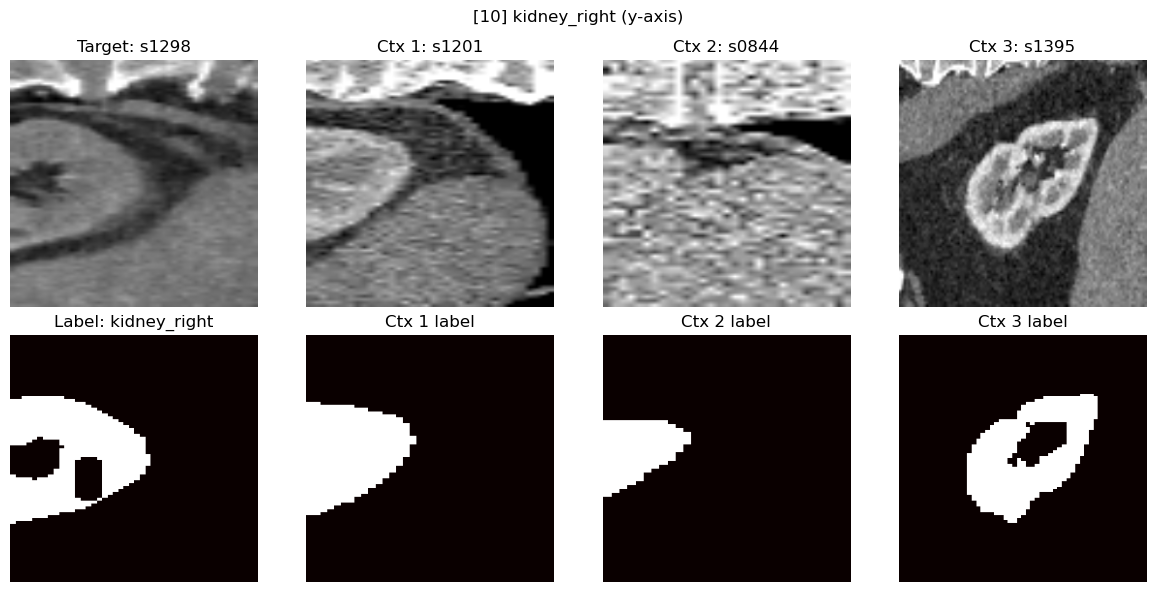

In [4]:
# Plot 5 random elements
import random

n_samples = 5
random_indices = random.sample(range(len(dataset)), n_samples)

for idx in random_indices:
    sample = dataset[idx]
    k = sample['context_in'].shape[0]
    
    fig, axes = plt.subplots(2, k + 1, figsize=(3 * (k + 1), 6))
    
    # Target
    axes[0, 0].imshow(sample['target_in'][0], cmap='gray')
    axes[0, 0].set_title(f"Target: {sample['target_case_id']}")
    axes[0, 0].axis('off')
    
    axes[1, 0].imshow(sample['target_out'][0], cmap='hot')
    axes[1, 0].set_title(f"Label: {sample['label_id']}")
    axes[1, 0].axis('off')
    
    # Contexts
    for i in range(k):
        axes[0, i + 1].imshow(sample['context_in'][i, 0], cmap='gray')
        axes[0, i + 1].set_title(f"Ctx {i+1}: {sample['context_case_ids'][i]}")
        axes[0, i + 1].axis('off')
        
        axes[1, i + 1].imshow(sample['context_out'][i, 0], cmap='hot')
        axes[1, i + 1].set_title(f"Ctx {i+1} label")
        axes[1, i + 1].axis('off')
    
    plt.suptitle(f"[{idx}] {sample['label_id']} ({sample['axis']}-axis)")
    plt.tight_layout()
    plt.show()